In [ ]:
!pip install paddleocr==2.9.1 paddlepaddle==2.6.2
!pip install pdf2image langchain langchain-text-splitters
!apt-get install poppler-utils -y
!apt-get install -y tesseract-ocr poppler-utils --quiet
!pip install pytesseract paddleocr==2.9.1 paddlepaddle==2.6.2 pdf2image langchain langchain-text-splitters easyocr --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 888.8 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.7/544.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s 

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12
Err:1 http://security.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12
  404  Not Found [IP: 91.189.92.23 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/p/poppler/poppler-utils_22.02.0-2ubuntu0.12_amd64.deb  404  Not Found [IP: 91.189.92.23 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed

In [ ]:
import sys
import types

m1 = types.ModuleType("langchain.docstore.document")
from langchain_core.documents import Document
m1.Document = Document
sys.modules["langchain.docstore.document"] = m1

m2 = types.ModuleType("langchain.text_splitter")
from langchain_text_splitters import RecursiveCharacterTextSplitter
m2.RecursiveCharacterTextSplitter = RecursiveCharacterTextSplitter
sys.modules["langchain.text_splitter"] = m2

print("Compatibility fix applied successfully!")

Compatibility fix applied successfully!


In [ ]:
from paddleocr import PaddleOCR
from pdf2image import convert_from_path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
import numpy as np
from google.colab import files
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
!apt-get update
!apt-get install poppler-utils -y
!which pdfinfo
!pdfinfo -v

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,332 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,614 kB]
H

Please upload your Pharmaceutical SDF file (PDF only): 


Saving pharmaceutical-sdf-page3-certificate-quality.pdf to pharmaceutical-sdf-page3-certificate-quality.pdf

Uploaded: pharmaceutical-sdf-page3-certificate-quality.pdf

Converting PDF to image...
Converted 1 page(s)


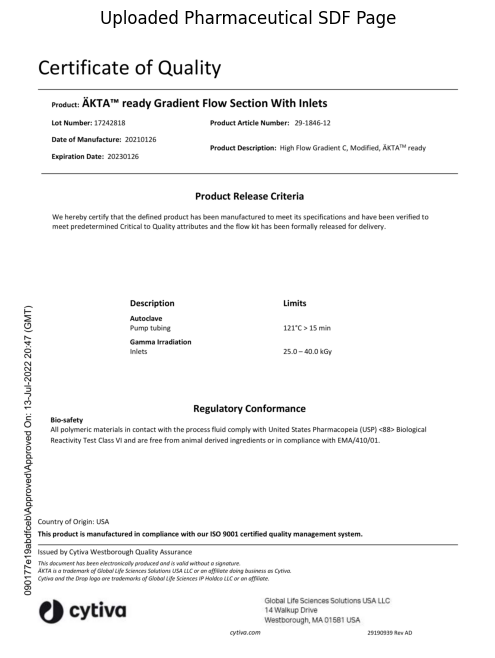

In [ ]:
print("Please upload your Pharmaceutical SDF file (PDF only): ")
uploadedfile = files.upload()

pdf_filename = list(uploadedfile.keys())[0]
pdf_path = f"/content/{pdf_filename}"
print(f"\nUploaded: {pdf_filename}")

print("\nConverting PDF to image...")
images = convert_from_path(pdf_path, dpi=300)
print(f"Converted {len(images)} page(s)")

image = images[0]
image_path = '/content/pharmaceutical_sdf.png'
image.save(image_path, 'PNG')

plt.figure(figsize=(12,8))
plt.imshow(image)
plt.title('Uploaded Pharmaceutical SDF Page')
plt.axis('off')
plt.show()

In [ ]:
print("Initialising PaddleOCR...")

ocr = PaddleOCR(
    use_angle_cls=True,
    lang='en'
)

print("\nPaddleOCR initialised and ready.")

Initialising PaddleOCR...
download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:03<00:00, 1262.38it/s]


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:00<00:00, 21773.81it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:00<00:00, 6449.34it/s]

[2026/07/09 12:27:18] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c


PaddleOCR initialised and ready.


In [ ]:
print("Running PaddleOCR on your pharmaceutical document...")
print("(Give us a moment!)")

result = ocr.ocr(image_path)

print("\nOCR complete!")
print(f"Detected {len(result[0]) if result[0] else 0} text regions")

Running PaddleOCR on your pharmaceutical document...
(Give us a moment!)
[2026/07/09 12:27:27] ppocr DEBUG: dt_boxes num : 36, elapsed : 0.5421593189239502
[2026/07/09 12:27:27] ppocr DEBUG: cls num  : 36, elapsed : 0.11248445510864258
[2026/07/09 12:27:38] ppocr DEBUG: rec_res num  : 36, elapsed : 11.199233531951904

OCR complete!
Detected 36 text regions


In [ ]:
print("Sample of PaddleOCR Results: ")
print("=" * 60)

for i, line in enumerate(result[0][:15]):
  box = line[0]
  text = line[1][0]
  confidence = line[1][1]

  print(f"{i+1:2d}. [{confidence: .2%}] {text}")

if len(result[0]) > 15:
  print(f"\n... and {len(result[0]) - 15} more text regions!")

Sample of PaddleOCR Results: 
 1. [ 99.94%] Certificate of Quality
 2. [ 96.58%] Product: AKTArM ready Gradient Flow Section With Inlets
 3. [ 99.11%] Lot Number: 17242818
 4. [ 99.02%] Product Article Number: 29-1846-12
 5. [ 99.81%] Date of Manufacture: 20210126
 6. [ 99.70%] Product Description: High Flow Gradient C, Modified, AKTATM ready
 7. [ 98.90%] Expiration Date: 20230126
 8. [ 97.57%] Product Release Criteria.
 9. [ 98.20%] We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
10. [ 98.49%] meet predetermined Critical to Quality attributes and the flow kit has been formally released for delivery.
11. [ 99.98%] Description
12. [ 99.90%] Limits
13. [ 95.03%]  On: 13-Jul-2022 20:47 (GMT)
14. [ 99.98%] Autoclave
15. [ 95.75%]  Pump tubing

... and 21 more text regions!


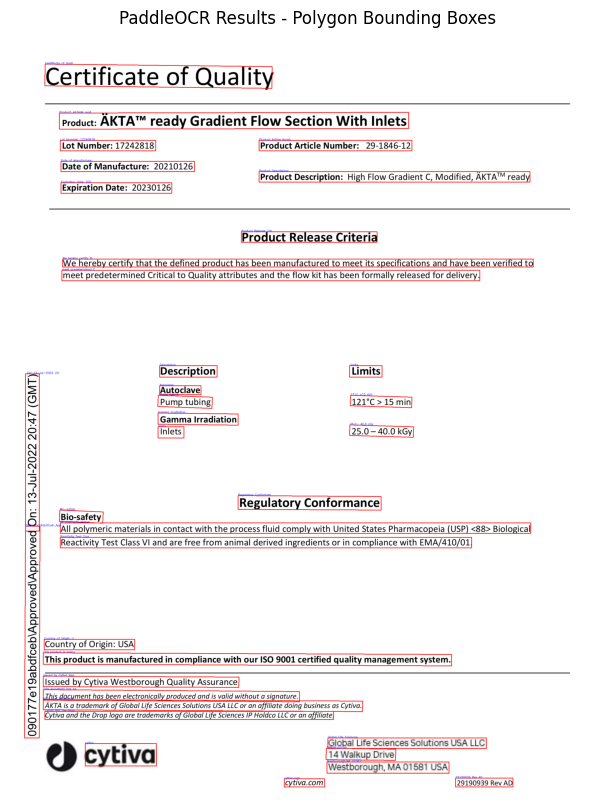

In [ ]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for line in result[0]:
  box = line[0]
  text = line[1][0]
  score = line[1][1]

  if score > 0.5:
    box = [(int(x), int(y)) for x, y in box]
    cv2.polylines(img, [np.array(box)], isClosed=True,
                  color=(255, 0, 0), thickness=2)
    cv2.putText(img, text[:20], box[0],
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)


plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.title('PaddleOCR Results - Polygon Bounding Boxes')
plt.axis('off')
plt.show()

In [ ]:
!pip install easyocr
!pip install -U sympy --quiet
import easyocr
print("\nEasyOCR installed and imported!")


EasyOCR installed and imported!


In [ ]:
print("Initialising EasyOCR...")

reader = easyocr.Reader(['en'])

print("\nEasyOCR initialised and ready.")

Initialising EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete
EasyOCR initialised and ready.


In [ ]:
print("Running EasyOCR on your pharmaceutical document...")
easy_result = reader.readtext(image_path)

print(f"\nEasyOCR found {len(easy_result)} text regions!")

Running EasyOCR on your pharmaceutical document...

EasyOCR found 47 text regions!


In [ ]:
print("Sample of EasyOCR Results: ")
print("=" * 60)

for i, (bbox, text, confidence) in enumerate(easy_result[:15]):
  print(f"{i+1:2d}. [{confidence: .2%}] {text}")

if len(easy_result) > 15:
  print(f"\n... and {len(easy_result) - 15} more text regions!")

Sample of EasyOCR Results: 
 1. [ 96.69%] Certificate of Quality
 2. [ 99.99%] Product:
 3. [ 81.38%] AKTATm
 4. [ 87.09%] ready Gradient Flow Section With Inlets
 5. [ 67.32%] Lot Number: 17242818
 6. [ 83.82%] Product Article Number:
 7. [ 98.10%] 29-1846-12
 8. [ 95.51%] Date of Manufacture: 20210126
 9. [ 83.95%] Product Description: High Flow Gradient C, Modified, AKTATM ready
10. [ 96.32%] Expiration Date: 20230126
11. [ 77.22%] Product Release Criteria
12. [ 81.51%] We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
13. [ 100.00%] meet
14. [ 72.91%] predetermined Critical to Quality attributes and the flow kit has been formally released for delivery:
15. [ 100.00%] Description

... and 32 more text regions!


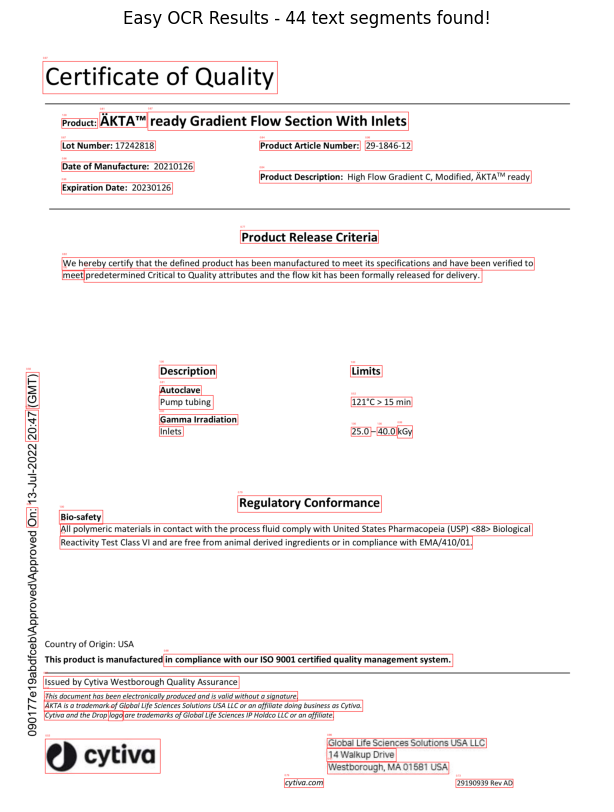

In [ ]:
img_easy = image.copy()
from PIL import ImageDraw
draw = ImageDraw.Draw(img_easy)

extracted_text = []

for (bbox, text, confidence) in easy_result:
  if confidence > 0.5:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    draw.rectangle([top_left, bottom_right], outline='red', width=2)
    draw.text((top_left[0], top_left[1] - 20), f"{confidence: .2f}", fill='red')
    extracted_text.append(text)

plt.figure(figsize=(15, 10))
plt.imshow(img_easy)
plt.title(f'Easy OCR Results - {len(extracted_text)} text segments found!')

plt.axis('off')
plt.show()

In [ ]:
import pytesseract
import cv2
import numpy as np
from PIL import Image
img_cv = cv2.imread(image_path)
gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
gray = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

scale_percent = 200
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_AREA)

tesseract_data = pytesseract.image_to_data(gray, config=r'--oem 3 -l eng', output_type=pytesseract.Output.DICT)

tesseract_text_list = []
tesseract_conf_list = []

for i in range(len(tesseract_data["text"])):
  word = tesseract_data["text"][i].strip()
  conf = int(tesseract_data["conf"][i])
  if word and conf > 0:
    tesseract_text_list.append(word)
    tesseract_conf_list.append(conf / 100)

print(f"Tesseract found {len(tesseract_text_list)} words!")

Tesseract found 216 words!


In [ ]:
paddle_count = len(result[0]) if result[0] else 0
paddle_confidences = [line[1][1] for line in result[0]] if result[0] else []
paddle_avg_conf = sum(paddle_confidences) / len(paddle_confidences) if paddle_confidences else 0

easy_count = len(easy_result)
easy_confidences = [conf for (_, _, conf) in easy_result]
easy_avg_conf = sum(easy_confidences) / len(easy_confidences) if easy_confidences else 0

tesseract_count = len(tesseract_text_list)
tesseract_avg_conf = sum(tesseract_conf_list) / len(tesseract_conf_list) if tesseract_conf_list else 0

print("OCR Engine Comparison")
print("=" * 70)
print(f"{'Metric':<25} {'Tesseract':<15} {'PaddleOCR':<15} {'EasyOCR':<15}")
print("-" * 70)
print(f"{'Text regions detected:':<25} {tesseract_count:<15} {paddle_count:<15} {easy_count:<15}")
print(f"{'Average confidence:':<25} {f'{tesseract_avg_conf:.2%}':<15} {f'{paddle_avg_conf:.2%}':<15} {f'{easy_avg_conf:.2%}':<15}")
print(f"{'High conf (>90%):':<25} {sum(1 for c in tesseract_conf_list if c > 0.9):<15} {sum(1 for c in paddle_confidences if c > 0.9):<15} {sum(1 for c in easy_confidences if c > 0.9):<15}")
print(f"{'Low conf (<50%):':<25} {sum(1 for c in tesseract_conf_list if c < 0.5):<15} {sum(1 for c in paddle_confidences if c < 0.5):<15} {sum(1 for c in easy_confidences if c < 0.5):<15}")

OCR Engine Comparison
Metric                    Tesseract       PaddleOCR       EasyOCR        
----------------------------------------------------------------------
Text regions detected:    216             36              47             
Average confidence:       92.01%          98.41%          79.12%         
High conf (>90%):         192             36              17             
Low conf (<50%):          5               0               3              


In [ ]:
key_terms = ["CERTIFICATE", "LOT", "BATCH", "VENDOR", "EXPIRATION", "DATE", "COA", "MANUFACTURER", 'CYTIVA', "QUALITY"]

paddle_texts = [line[1][0]. upper() for line in result[0]] if result[0] else []
easy_texts = [text.upper() for (_, text, _) in easy_result]
tesseract_texts = [word.upper() for word in tesseract_text_list]

print("Key Pharmaceutical Terms Found:")
print("=" * 50)
print(f"{'Term':<15} {'PaddleOCR':<12} {'EasyOCR':<12} {'Tesseract':<12}")
print("-" * 50)


for term in key_terms:
  paddle_found = any(term in text for text in paddle_texts)
  easy_found = any(term in text for text in easy_texts)
  tess_found = any(term in text for text in tesseract_texts)


  paddle_mark = "Found" if paddle_found else "--"
  easy_mark = "Found" if easy_found else "--"
  tess_mark = "Found" if paddle_found else "--"

  print(f"{term:<15} {paddle_mark:<12} {easy_mark:<12} {tess_mark:<12}")

Key Pharmaceutical Terms Found:
Term            PaddleOCR    EasyOCR      Tesseract   
--------------------------------------------------
CERTIFICATE     Found        Found        Found       
LOT             Found        Found        Found       
BATCH           --           --           --          
VENDOR          --           --           --          
EXPIRATION      Found        Found        Found       
DATE            Found        Found        Found       
COA             --           --           --          
MANUFACTURER    --           --           --          
CYTIVA          Found        Found        Found       
QUALITY         Found        Found        Found       
